# Notebook 2 — Exploratory Data Analysis (EDA)

Loads `data/raw_combined.parquet` and explores the dataset visually to build intuition
before feature engineering. Key questions:
- How balanced are the classes?
- Which protocols dominate each attack type?
- How does packet length differ across classes?
- Are there dominant source/destination IPs?
- How fast do packets arrive (inter-arrival time)?

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data')
PLOTS_DIR = DATA_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

df = pd.read_parquet(DATA_DIR / 'raw_combined.parquet')
print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
df.head(3)

Loaded 151,062 rows x 9 columns


,no,time,source,destination,protocol,length,info,label,src_file
0,10001,375.057687,192.168.239.25,239.255.255.250,SSDP,167,M-SEARCH * HTTP/1.1,Benign,dataset\benign\benign-1.csv
1,10002,375.062327,2600:1901:1:b05::,2409:40f4:100b:c1b6:b9fb:3ec3:5675:a236,TLSv1.3,749,"Application Data, Application Data",Benign,dataset\benign\benign-1.csv
2,10003,375.062460,2409:40f4:100b:c1b6:b9fb:3ec3:5675:a236,2600:1901:1:b05::,TCP,86,60888 > 443 [ACK] Seq=1505 Ack=4066 Win=6361...,Benign,dataset\benign\benign-1.csv


## 1. Class distribution

             count    pct
label                    
Exploit      61462  40.69
Flood        29336  19.42
Benign       22084  14.62
Brute_Force  19551  12.94
Probe        11629   7.70
Malware       7000   4.63


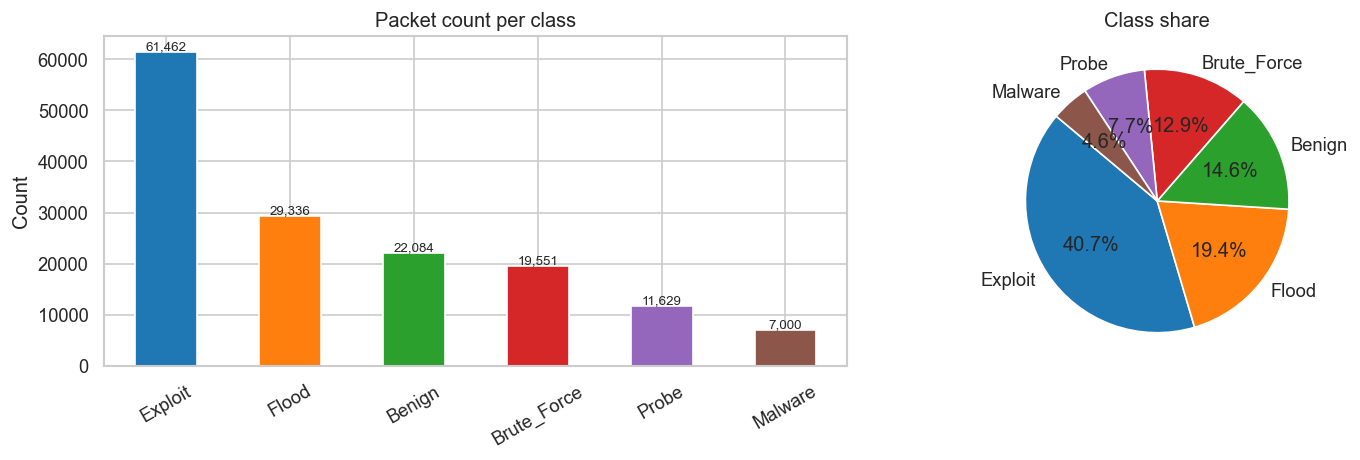

In [2]:
class_counts = df['label'].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)

summary = pd.DataFrame({'count': class_counts, 'pct': class_pct})
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = sns.color_palette('tab10', len(class_counts))
class_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Packet count per class')
axes[0].set_xlabel(''); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Class share')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_class_distribution.png')
plt.show()

## 2. Protocol distribution per class

Each attack type tends to use specific protocols — this is a key discriminating feature.

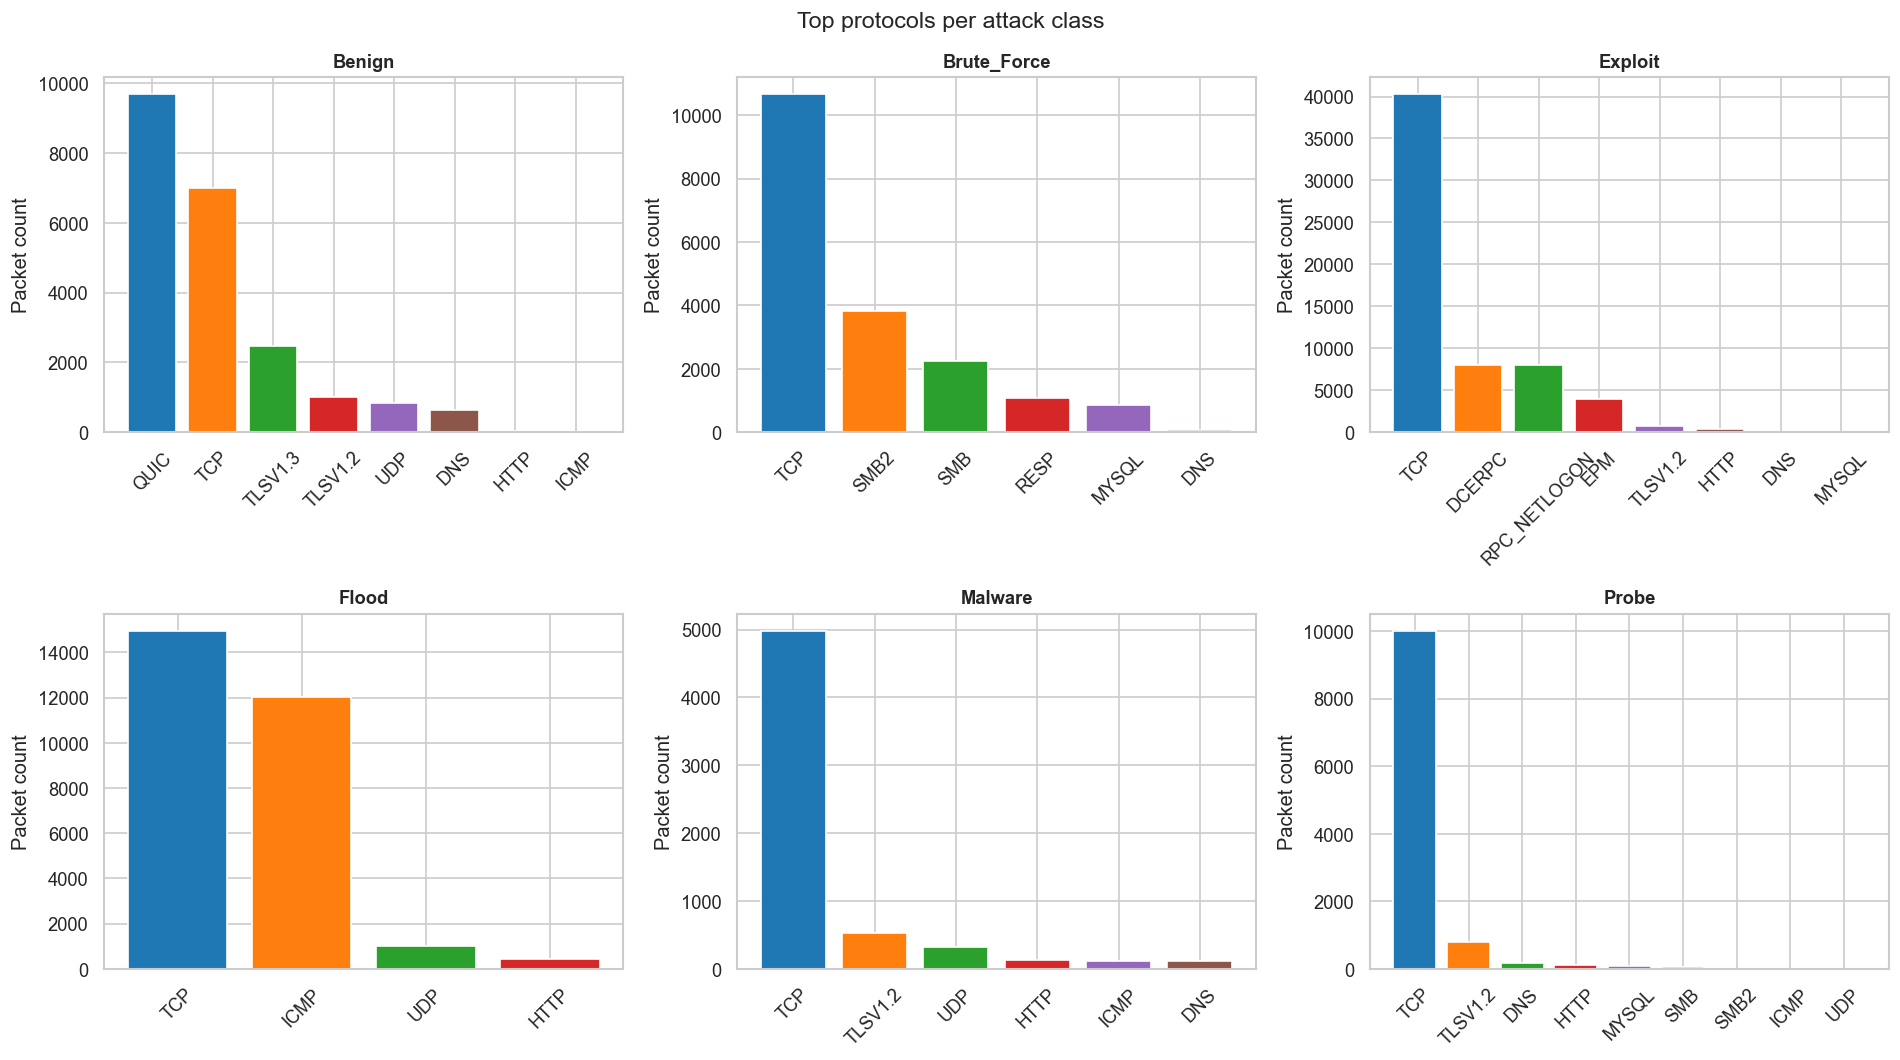

In [3]:
df['protocol'] = df['protocol'].fillna('UNKNOWN').astype(str).str.upper().str.strip()

# Top N protocols overall
top_protocols = df['protocol'].value_counts().head(15).index.tolist()
df_proto = df[df['protocol'].isin(top_protocols)]

proto_class = (df_proto
               .groupby(['label', 'protocol'])
               .size()
               .reset_index(name='count'))

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for i, label in enumerate(df['label'].unique()):
    sub = proto_class[proto_class['label'] == label].nlargest(10, 'count')
    axes[i].bar(sub['protocol'], sub['count'],
                color=sns.color_palette('tab10', len(sub)))
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Packet count')

plt.suptitle('Top protocols per attack class', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_protocol_per_class.png')
plt.show()

## 3. Packet length distribution per class

Flood attacks often use fixed-size packets; malware may have variable-length payloads.

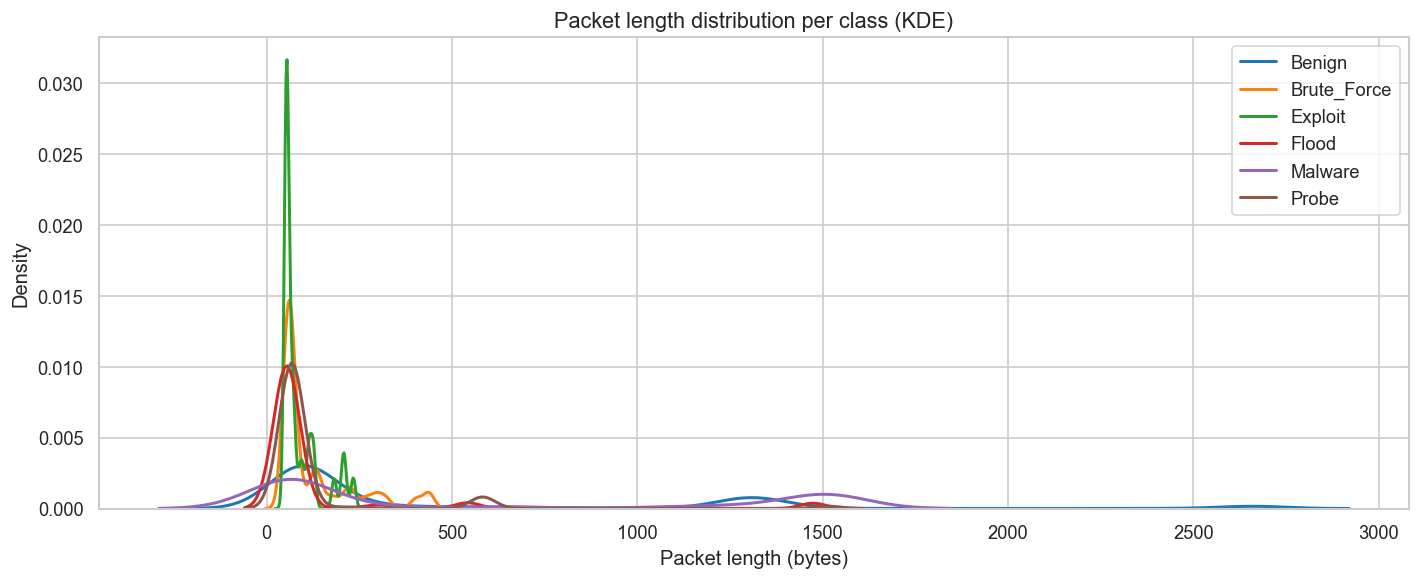

               count   mean    std   min   25%    50%     75%     max
label                                                                
Benign       22084.0  468.5  659.6  42.0  86.0  101.0   624.5  6054.0
Brute_Force  19551.0  136.3  134.5  42.0  60.0   66.0   178.0  1514.0
Exploit      61462.0   98.0  101.3  42.0  54.0   66.0   114.0  1514.0
Flood        29336.0  140.2  340.5  42.0  42.0   58.0    66.0  3459.0
Malware       7000.0  579.8  652.0  42.0  60.0   77.0  1514.0  1514.0
Probe        11629.0  130.8  220.2  42.0  66.0   66.0    74.0  1514.0


In [4]:
df['length'] = pd.to_numeric(df['length'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))

for label, grp in df.groupby('label'):
    lengths = grp['length'].dropna()
    # clip to 99th percentile for readability
    cap = lengths.quantile(0.99)
    lengths = lengths[lengths <= cap]
    sns.kdeplot(lengths, ax=ax, label=label, fill=False, linewidth=1.8)

ax.set_title('Packet length distribution per class (KDE)', fontsize=13)
ax.set_xlabel('Packet length (bytes)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_length_distribution.png')
plt.show()

# Summary stats
print(df.groupby('label')['length'].describe().round(1).to_string())

## 4. Inter-arrival time (IAT) analysis

IAT = time between consecutive packets. Flood attacks have very small, regular IATs.

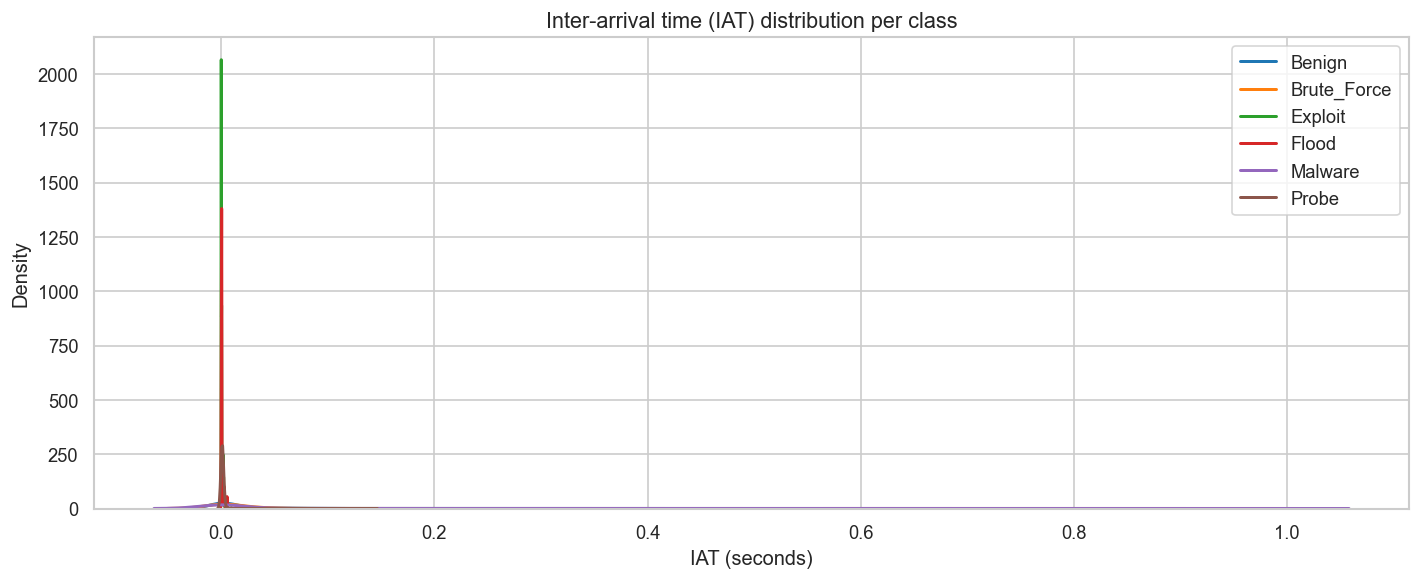


Mean IAT per class (seconds):
label
Benign         0.0615
Brute_Force    0.0612
Exploit        0.0037
Flood          0.0147
Malware        0.2645
Probe          0.0330
Name: iat, dtype: float64


In [5]:
df['time'] = pd.to_numeric(df['time'], errors='coerce')

# Compute IAT per (file, label) group to avoid cross-file artifacts
df_sorted = df.sort_values(['src_file', 'time'])
df_sorted['iat'] = df_sorted.groupby('src_file')['time'].diff().fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))

for label, grp in df_sorted.groupby('label'):
    iat = grp['iat'].dropna()
    cap = min(iat.quantile(0.98), 1.0)   # clip to 1 second for readability
    iat = iat[(iat >= 0) & (iat <= cap)]
    if len(iat) > 10:
        sns.kdeplot(iat, ax=ax, label=label, fill=False, linewidth=1.8)

ax.set_title('Inter-arrival time (IAT) distribution per class', fontsize=13)
ax.set_xlabel('IAT (seconds)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '04_iat_distribution.png')
plt.show()

print('\nMean IAT per class (seconds):')
print(df_sorted[df_sorted['iat'] >= 0].groupby('label')['iat'].mean().round(4))

## 5. Top source IPs per attack class

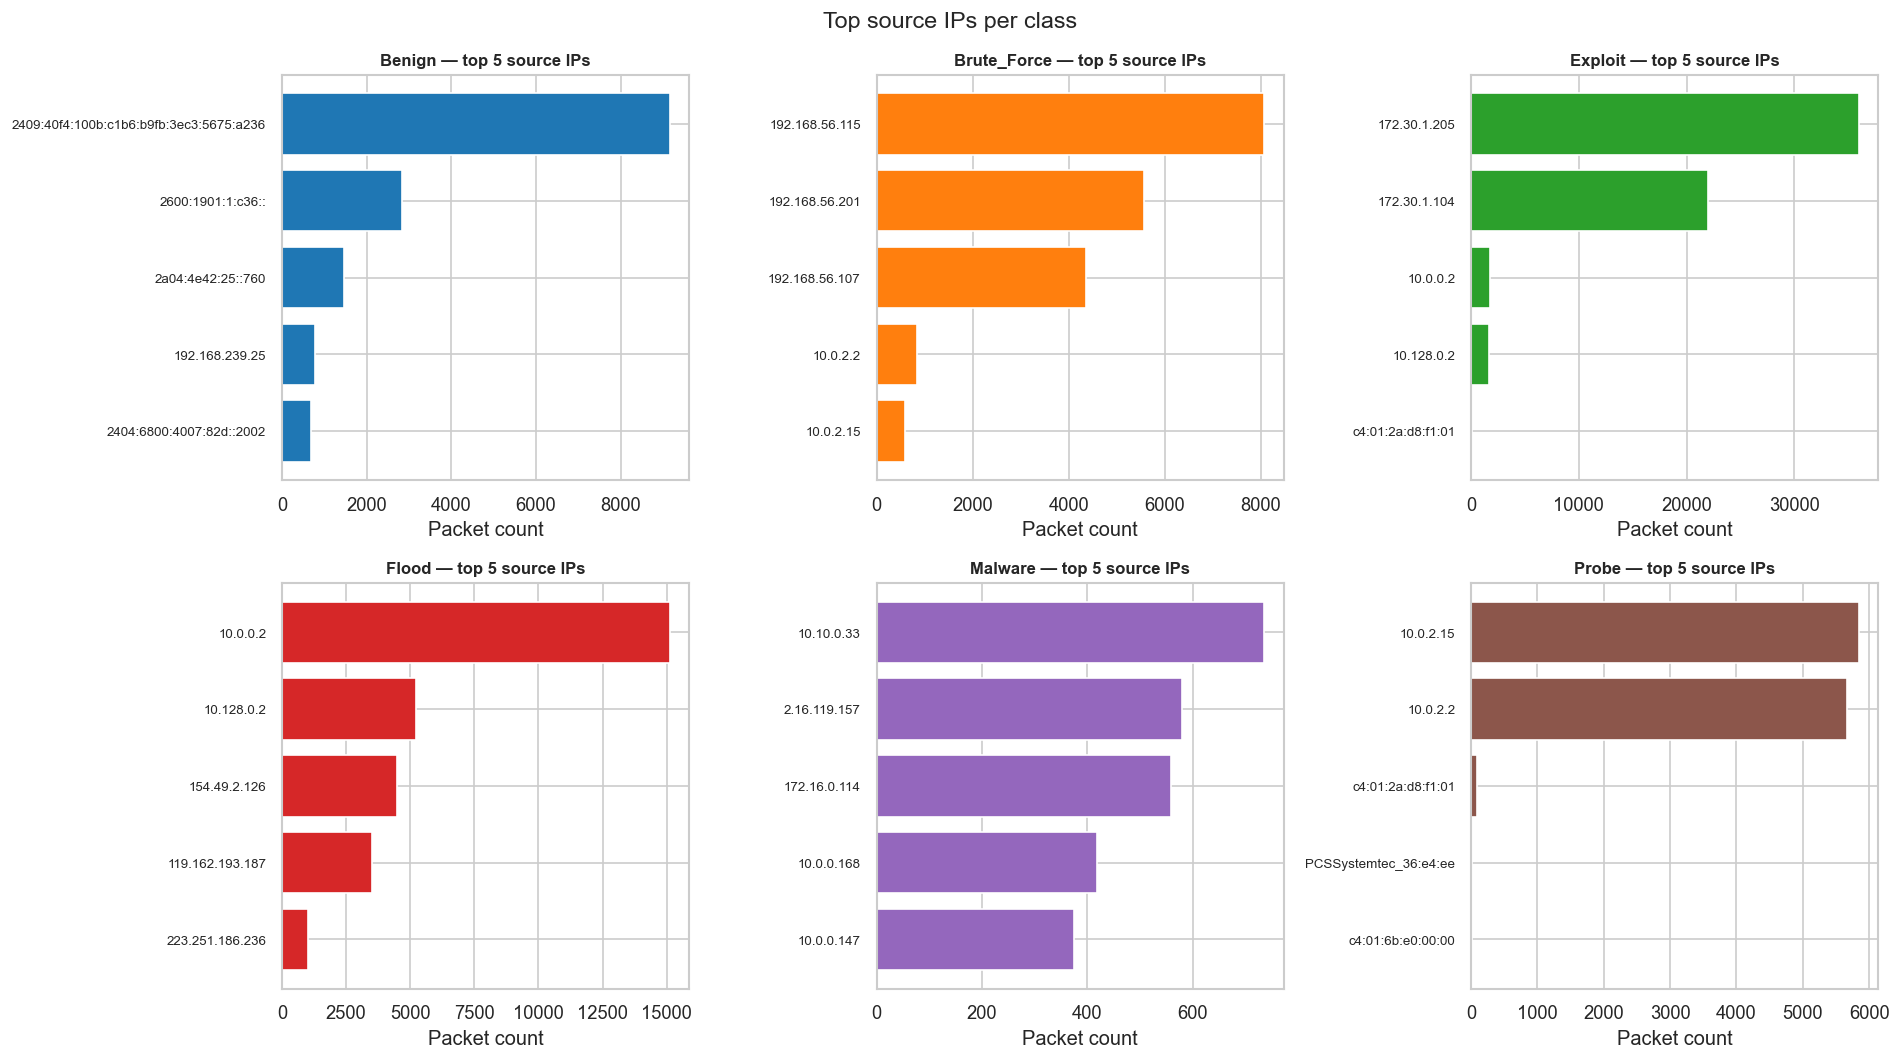

In [6]:
df['source']      = df['source'].fillna('unknown').astype(str)
df['destination'] = df['destination'].fillna('unknown').astype(str)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (label, grp) in enumerate(df.groupby('label')):
    top_src = grp['source'].value_counts().head(5)
    axes[i].barh(top_src.index[::-1], top_src.values[::-1],
                 color=sns.color_palette('tab10')[i])
    axes[i].set_title(f'{label} — top 5 source IPs', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Packet count')
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Top source IPs per class', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_top_source_ips.png')
plt.show()

## 6. Correlation heatmap of numeric features

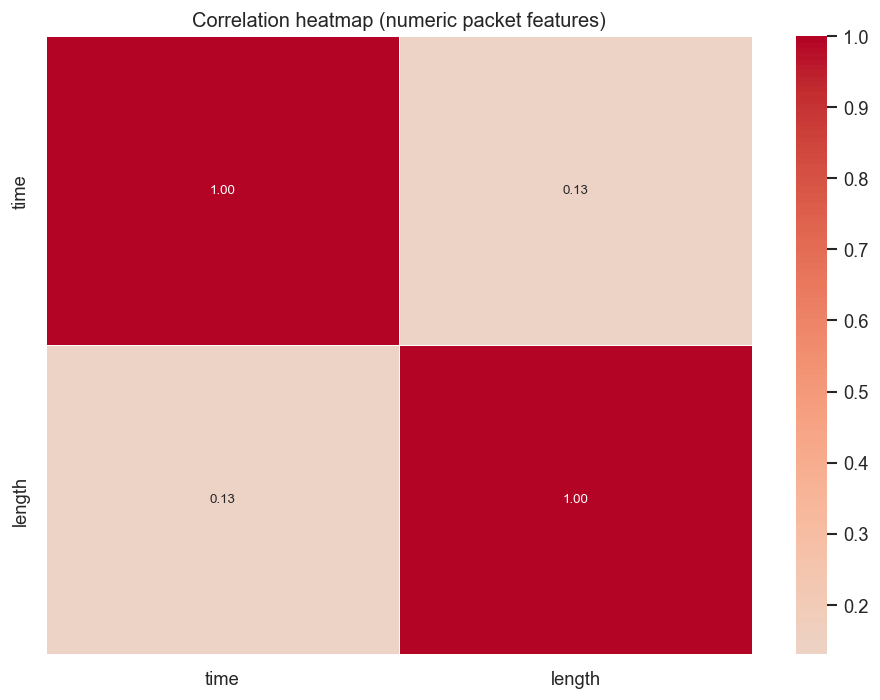

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove irrelevant columns
numeric_cols = [c for c in numeric_cols if c not in ['no']]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation heatmap (numeric packet features)', fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '06_correlation_heatmap.png')
plt.show()

## 7. Packet length boxplot per class

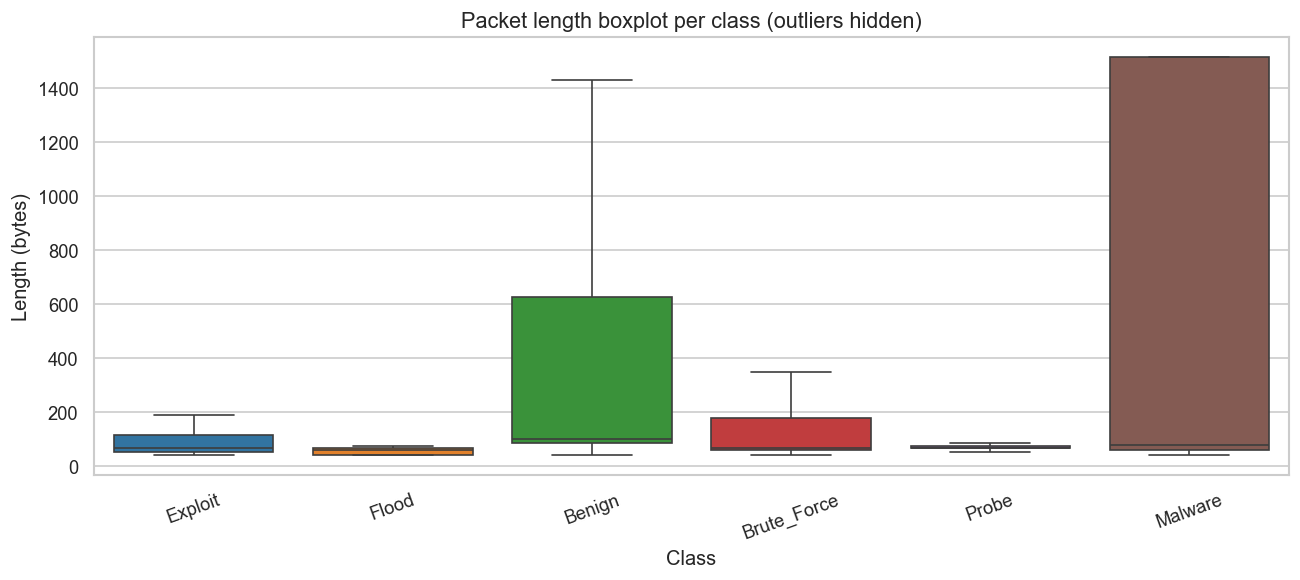

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
order = df['label'].value_counts().index.tolist()
sns.boxplot(data=df, x='label', y='length', order=order,
            palette='tab10', showfliers=False, ax=ax)
ax.set_title('Packet length boxplot per class (outliers hidden)', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Length (bytes)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '07_length_boxplot.png')
plt.show()

## ✅ Notebook 2 complete
All plots saved to `data/plots/`.  
**Key findings to carry into feature engineering:**
- Flood attacks have very low, regular IAT and fixed packet lengths
- Protocol is a strong discriminator (UDP→Flood, TCP→BruteForce/Exploit)
- Malware has more variable packet sizes
- Some classes (e.g. Probe) may have few samples → SMOTE needed

**Next:** Run `03_feature_engineering.ipynb`